In [5]:
# ================================================================
# PART 3 — CELL 1: Setup (Customer Support Sentiment NLP)
# Dataset: customer_support_text_classification.csv
# Text column: customer_message
# Label column: sentiment_label (positive / neutral / negative)
# ================================================================
import os, re, warnings, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
os.makedirs('results',exist_ok=True)

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk; nltk.download('stopwords',quiet=True)
from nltk.corpus import stopwords
print(f"TensorFlow {tf.__version__}  ✅")

# ⚠️  UPDATE THIS PATH
DATA_PATH='/content/drive/MyDrive/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv'

df=pd.read_csv(DATA_PATH)
print(f"Loaded! Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

# Fixed column names — confirmed from dataset description
TEXT_COL  = 'customer_message'
LABEL_COL = 'sentiment_label'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow 2.20.0  ✅
Loaded! Shape: (1500, 6)
Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  



===== TASK 1: DATASET UNDERSTANDING =====
Total records: 1500

Sentiment distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Avg message length (chars): 73
Avg word count (from col): 12.7

Channel distribution:
channel
email     326
social    314
phone     296
chat      290
app       274
Name: count, dtype: int64

Urgent flag:
urgent_flag
0    1100
1     400
Name: count, dtype: int64


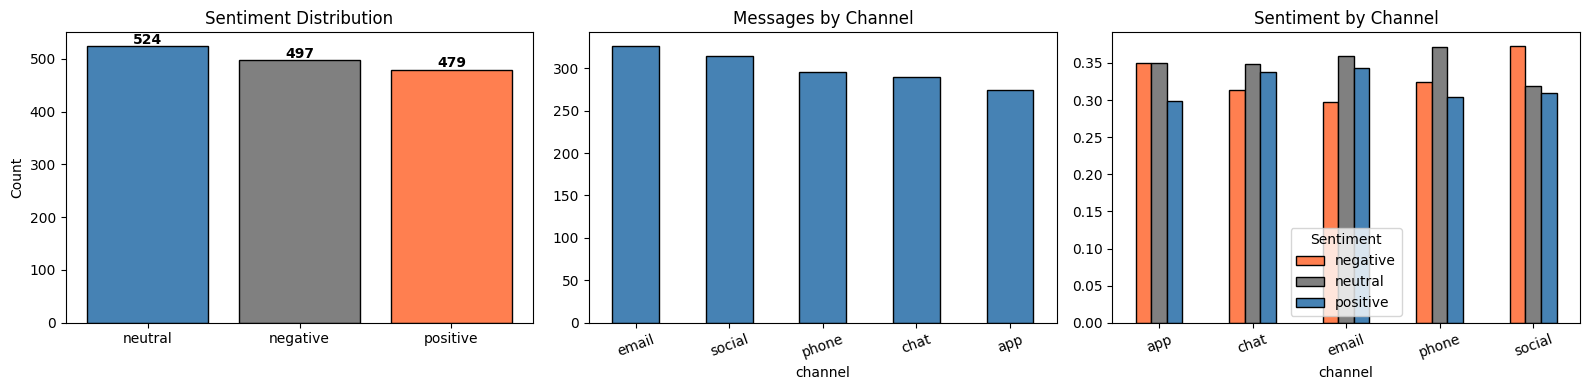


Sample messages:
  [neutral] I need information about the payment process. My ticket number is 78732. Please respond as...
  [neutral] I need information about the payment process....
  [positive] The refund process was fast and convenient. I appreciate the quick response....

===== TASK 2: TEXT PREPROCESSING =====
Before/after cleaning samples:
  Original: I need information about the payment process. My ticket number is 78732. Please respond as...
  Cleaned:  need information payment process ticket number please respond soon possible...

  Original: I need information about the payment process....
  Cleaned:  need information payment process...

Avg tokens after cleaning: 6.6

===== TASK 3: TEXT VECTORISATION =====
Why vectorise text?
TF-IDF converts each message to a vector where each dimension = one word.
Value = TF * IDF:
  TF  = how often the word appears in this message
  IDF = log(total docs / docs containing this word)
Words like 'broken', 'refund', 'angry' score high in nega

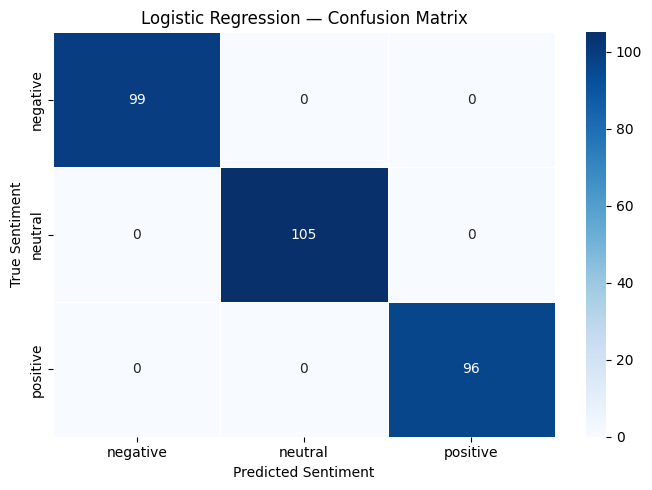


===== TASK 5: BIDIRECTIONAL LSTM =====
Vocab size: 148  |  Seq shape: (1200, 150)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Bidirectional LSTM...
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 771ms/step - accuracy: 0.3302 - loss: 1.1008 - val_accuracy: 0.3375 - val_loss: 1.1020
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 560ms/step - accuracy: 0.3333 - loss: 1.1003 - val_accuracy: 0.3375 - val_loss: 1.1013
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - accuracy: 0.3458 - loss: 1.0983 - val_accuracy: 0.3375 - val_loss: 1.1007
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 283ms/step - accuracy: 0.3208 - loss: 1.1001 - val_accuracy: 0.3375 - val_loss: 1.1018
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 307ms/step - accuracy: 0.3469 - loss: 1.0973 - val_accuracy: 0.3375 - val_loss: 1.1039
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step - accuracy: 0.3490 - loss: 1.0982 - val_accuracy: 0.3375 - val_loss: 1.1006


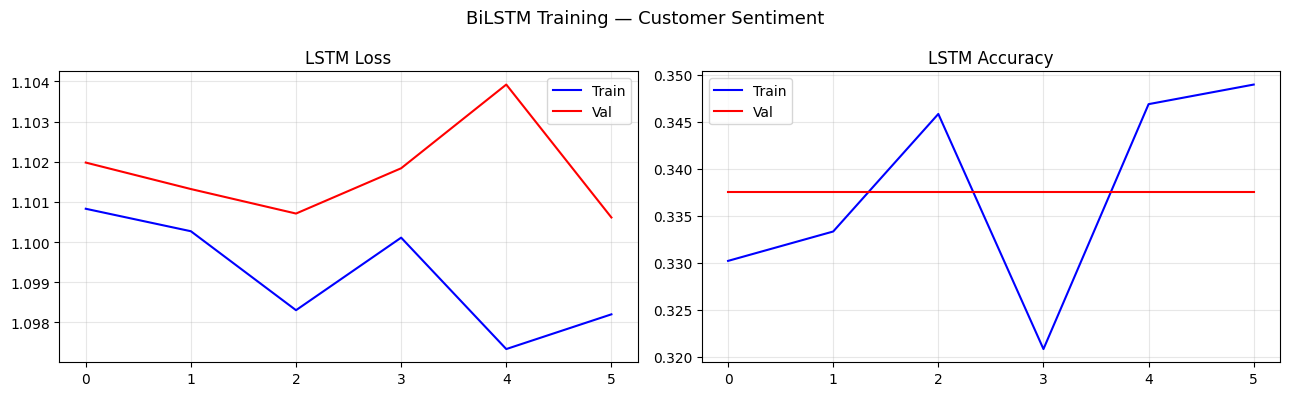


LSTM Accuracy: 0.3500
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        99
     neutral       0.35      1.00      0.52       105
    positive       0.00      0.00      0.00        96

    accuracy                           0.35       300
   macro avg       0.12      0.33      0.17       300
weighted avg       0.12      0.35      0.18       300



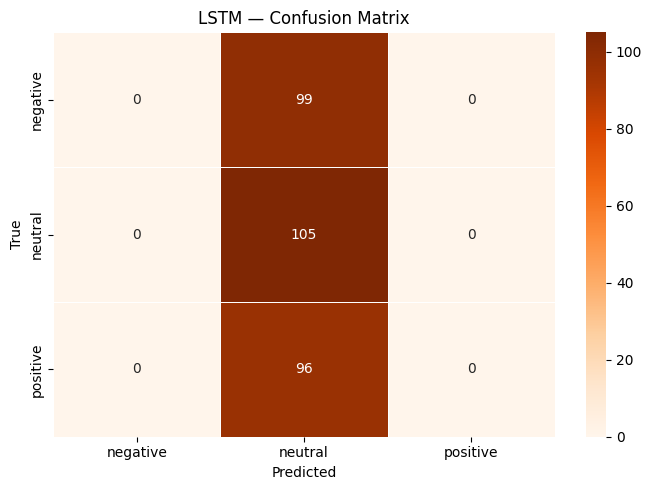


===== MODEL COMPARISON =====
              Model   Vectorisation           Type Test Accuracy
Logistic Regression          TF-IDF Traditional ML        1.0000
        Naive Bayes          TF-IDF Traditional ML        1.0000
 Bidirectional LSTM Word Embeddings  Deep Learning        0.3500


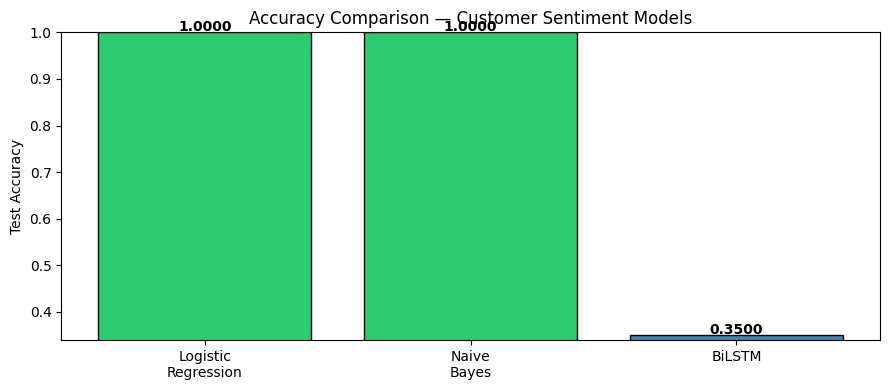

✗  True:positive | Pred:neutral (34.5%)
   like new payment easy use ticket number...

✗  True:positive | Pred:neutral (34.5%)
   great service clear communication support team...

✗  True:negative | Pred:neutral (34.5%)
   refund still pending experience frustrating...

✗  True:negative | Pred:neutral (34.5%)
   app crashes whenever try use analytics...

✗  True:positive | Pred:neutral (34.5%)
   response team helpful professional...

✓  True:neutral | Pred:neutral (34.5%)
   someone explain difference plans...

✗  True:positive | Pred:neutral (34.5%)
   like new video call easy use...

✗  True:positive | Pred:neutral (34.5%)
   like new report download easy use...

✓  True:neutral | Pred:neutral (34.5%)
   someone explain difference plans...

✓  True:neutral | Pred:neutral (34.5%)
   want understand warranty terms product...

✅ All results saved!

===== TASK 6: REFLECTION =====

1. WHY RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES
   RNNs overwrite the hidden state at each word. In a lon

In [6]:
# ================================================================
# PART 3 — CELL 2: Full NLP Notebook (all 6 tasks)
# ================================================================

# ── TASK 1: DATASET UNDERSTANDING ────────────────────────────
print("\n===== TASK 1: DATASET UNDERSTANDING =====")
print(f"Total records: {len(df)}")
print(f"\nSentiment distribution:\n{df[LABEL_COL].value_counts()}")
print(f"\nAvg message length (chars): {df[TEXT_COL].astype(str).apply(len).mean():.0f}")
print(f"Avg word count (from col): {df['word_count'].mean():.1f}")
print(f"\nChannel distribution:\n{df['channel'].value_counts()}")
print(f"\nUrgent flag:\n{df['urgent_flag'].value_counts()}")

fig,axes=plt.subplots(1,3,figsize=(16,4))

counts=df[LABEL_COL].value_counts()
axes[0].bar(counts.index,counts.values,
            color=['steelblue','gray','coral'],edgecolor='black')
axes[0].set_title('Sentiment Distribution'); axes[0].set_ylabel('Count')
for i,(l,n) in enumerate(counts.items()):
    axes[0].text(i,n+5,str(n),ha='center',fontweight='bold')

df['channel'].value_counts().plot(kind='bar',ax=axes[1],color='steelblue',edgecolor='black')
axes[1].set_title('Messages by Channel'); axes[1].tick_params(axis='x',rotation=20)

pd.crosstab(df['channel'],df[LABEL_COL],normalize='index').plot(
    kind='bar',ax=axes[2],color=['coral','gray','steelblue'],edgecolor='black')
axes[2].set_title('Sentiment by Channel'); axes[2].tick_params(axis='x',rotation=20)
axes[2].legend(title='Sentiment')

plt.tight_layout(); plt.savefig('results/dataset_overview.png',dpi=150); plt.show()
print("\nSample messages:")
for i in range(3):
    print(f"  [{df[LABEL_COL].iloc[i]}] {str(df[TEXT_COL].iloc[i])[:90]}...")

# ── TASK 2: TEXT PREPROCESSING ───────────────────────────────
print("\n===== TASK 2: TEXT PREPROCESSING =====")
STOP=set(stopwords.words('english'))

def clean(txt):
    txt=str(txt).lower()
    txt=re.sub(r'http\S+|www\S+','',txt)   # remove URLs
    txt=re.sub(r'[^a-z\s]','',txt)           # keep letters only
    txt=re.sub(r'\s+',' ',txt).strip()       # clean whitespace
    return ' '.join(w for w in txt.split() if w not in STOP and len(w)>2)

df['clean_msg']=df[TEXT_COL].apply(clean)
print("Before/after cleaning samples:")
for i in range(2):
    print(f"  Original: {str(df[TEXT_COL].iloc[i])[:90]}...")
    print(f"  Cleaned:  {df['clean_msg'].iloc[i][:90]}...\n")

df['clean_len']=df['clean_msg'].apply(lambda x: len(x.split()))
print(f"Avg tokens after cleaning: {df['clean_len'].mean():.1f}")

# ── TASK 3: TEXT VECTORISATION ───────────────────────────────
print("\n===== TASK 3: TEXT VECTORISATION =====")
print("""Why vectorise text?
TF-IDF converts each message to a vector where each dimension = one word.
Value = TF * IDF:
  TF  = how often the word appears in this message
  IDF = log(total docs / docs containing this word)
Words like 'broken', 'refund', 'angry' score high in negative messages
but low across all messages, giving them high TF-IDF weight.
""")

le=LabelEncoder()
y=le.fit_transform(df[LABEL_COL])
N_CLS=len(le.classes_)
print(f"Label encoding: {dict(zip(le.classes_,range(N_CLS)))}")

# Single split used by BOTH models — prevents data leakage
X_tr_raw,X_te_raw,y_train,y_test=train_test_split(
    df['clean_msg'].values,y,test_size=.2,random_state=42,stratify=y)
print(f"Train: {len(X_tr_raw)}  |  Test: {len(X_te_raw)}")

tfidf=TfidfVectorizer(max_features=8000,ngram_range=(1,2),min_df=2)
X_tr_tfidf=tfidf.fit_transform(X_tr_raw)   # fit on TRAIN only
X_te_tfidf=tfidf.transform(X_te_raw)       # transform TEST with same vocab
print(f"TF-IDF matrix: {X_tr_tfidf.shape}  (docs × features)")

# ── TASK 4: BASELINE MODELS ──────────────────────────────────
print("\n===== TASK 4: BASELINE MODELS =====")

# Model A: Logistic Regression
lr=LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced')
lr.fit(X_tr_tfidf,y_train)
lr_pred=lr.predict(X_te_tfidf)
lr_acc=accuracy_score(y_test,lr_pred)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(classification_report(y_test,lr_pred,target_names=le.classes_))

# Model B: Naive Bayes
import scipy.sparse as sp
X_tr_nb=sp.csr_matrix(X_tr_tfidf.toarray().clip(min=0))
X_te_nb=sp.csr_matrix(X_te_tfidf.toarray().clip(min=0))
nb=MultinomialNB(); nb.fit(X_tr_nb,y_train)
nb_pred=nb.predict(X_te_nb); nb_acc=accuracy_score(y_test,nb_pred)
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")

cm_lr=confusion_matrix(y_test,lr_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='Blues',linewidths=.5,
            xticklabels=le.classes_,yticklabels=le.classes_)
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('True Sentiment'); plt.xlabel('Predicted Sentiment')
plt.tight_layout(); plt.savefig('results/baseline_confusion_matrix.png',dpi=150); plt.show()

# ── TASK 5: LSTM SEQUENCE MODEL ──────────────────────────────
print("\n===== TASK 5: BIDIRECTIONAL LSTM =====")
MAX_V,MAX_L,EMBED=12000,150,128

tok=Tokenizer(num_words=MAX_V,oov_token='<OOV>')
tok.fit_on_texts(X_tr_raw)                         # fit on train only
X_tr_seq=pad_sequences(tok.texts_to_sequences(X_tr_raw),maxlen=MAX_L,padding='post')
X_te_seq=pad_sequences(tok.texts_to_sequences(X_te_raw),maxlen=MAX_L,padding='post')
print(f"Vocab size: {min(len(tok.word_index)+1,MAX_V)}  |  Seq shape: {X_tr_seq.shape}")

lstm_model=keras.Sequential([
    layers.Embedding(MAX_V,EMBED,input_length=MAX_L,name='embedding'),
    layers.SpatialDropout1D(.2),
    layers.Bidirectional(layers.LSTM(64,return_sequences=True),name='bilstm'),
    layers.LSTM(32,name='lstm2'),
    layers.Dense(64,activation='relu',name='dense1'),
    layers.Dropout(.4),
    layers.Dense(N_CLS,activation='softmax',name='output')  # 3 sentiments
])
lstm_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='sparse_categorical_crossentropy',metrics=['accuracy'])
lstm_model.summary()

print("\nTraining Bidirectional LSTM...")
h=lstm_model.fit(X_tr_seq,y_train,epochs=20,batch_size=32,validation_split=.2,
    callbacks=[EarlyStopping(monitor='val_accuracy',patience=5,
                              restore_best_weights=True,mode='max')],verbose=1)

fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(h.history['loss'],label='Train',color='blue')
axes[0].plot(h.history['val_loss'],label='Val',color='red')
axes[0].set_title('LSTM Loss'); axes[0].legend(); axes[0].grid(True,alpha=.3)
axes[1].plot(h.history['accuracy'],label='Train',color='blue')
axes[1].plot(h.history['val_accuracy'],label='Val',color='red')
axes[1].set_title('LSTM Accuracy'); axes[1].legend(); axes[1].grid(True,alpha=.3)
plt.suptitle('BiLSTM Training — Customer Sentiment',fontsize=13)
plt.tight_layout(); plt.savefig('results/lstm_training_curves.png',dpi=150); plt.show()

lp_prob=lstm_model.predict(X_te_seq,verbose=0)
lp_cls=np.argmax(lp_prob,1)
lstm_acc=accuracy_score(y_test,lp_cls)
print(f"\nLSTM Accuracy: {lstm_acc:.4f}")
print(classification_report(y_test,lp_cls,target_names=le.classes_))

cm_l=confusion_matrix(y_test,lp_cls)
plt.figure(figsize=(7,5))
sns.heatmap(cm_l,annot=True,fmt='d',cmap='Oranges',linewidths=.5,
            xticklabels=le.classes_,yticklabels=le.classes_)
plt.title('LSTM — Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig('results/lstm_confusion_matrix.png',dpi=150); plt.show()

# Comparison table
comp=pd.DataFrame({'Model':['Logistic Regression','Naive Bayes','Bidirectional LSTM'],
    'Vectorisation':['TF-IDF','TF-IDF','Word Embeddings'],
    'Type':['Traditional ML','Traditional ML','Deep Learning'],
    'Test Accuracy':[f"{lr_acc:.4f}",f"{nb_acc:.4f}",f"{lstm_acc:.4f}"]})
print("\n===== MODEL COMPARISON =====")
print(comp.to_string(index=False))
comp.to_csv('results/model_evaluation.csv',index=False)

plt.figure(figsize=(9,4))
accs=[lr_acc,nb_acc,lstm_acc]; nms=['Logistic\nRegression','Naive\nBayes','BiLSTM']
best=max(accs); cols=['#2ecc71' if a==best else 'steelblue' for a in accs]
bars=plt.bar(nms,accs,color=cols,edgecolor='black')
[plt.text(b.get_x()+b.get_width()/2,b.get_height()+.003,f'{a:.4f}',ha='center',fontweight='bold')
 for b,a in zip(bars,accs)]
plt.title('Accuracy Comparison — Customer Sentiment Models')
plt.ylabel('Test Accuracy'); plt.ylim(max(0,min(accs)*.97),min(1,max(accs)*1.03))
plt.tight_layout(); plt.savefig('results/model_comparison.png',dpi=150); plt.show()

# Sample predictions
with open('results/sample_predictions.txt','w') as f:
    f.write("SAMPLE PREDICTIONS — LSTM\nCustomer Support Sentiment Analysis\n"+"="*60+"\n\n")
    for i in range(min(10,len(X_te_raw))):
        tl=le.classes_[y_test[i]]; pl=le.classes_[lp_cls[i]]
        conf=np.max(lp_prob[i])*100; ok='✓' if tl==pl else '✗'
        line=f"{ok}  True:{tl} | Pred:{pl} ({conf:.1f}%)\n   {X_te_raw[i][:100]}...\n\n"
        f.write(line); print(line,end='')

print("✅ All results saved!")

# ── TASK 6: REFLECTION ───────────────────────────────────────
print("""
===== TASK 6: REFLECTION =====

1. WHY RNNs STRUGGLE WITH LONG-TERM DEPENDENCIES
   RNNs overwrite the hidden state at each word. In a long customer message
   the first sentence is effectively forgotten by the last. Gradients shrink
   exponentially through backpropagation-through-time (vanishing gradient).

2. HOW LSTMs HELP WITH MEMORY
   Three gates control information flow:
   Forget gate: decides what previous context to discard
   Input gate:  decides what new information from current word to add
   Output gate: decides what to pass to the next step and to the output
   This lets the model remember that a message started with 'I am very
   unhappy' even after processing 50 more words.

3. WHAT ATTENTION SOLVES
   Attention removes the bottleneck of a single fixed-size vector. Instead,
   the decoder can look at every encoder position simultaneously. For
   sentiment: words like 'broken', 'refund', 'angry' are weighted higher
   regardless of their position in the message.

4. WHY TRANSFORMERS MATTER IN MODERN NLP
   Transformers use ONLY self-attention — no recurrence — enabling full
   parallelism during training (GPUs work 100x faster). BERT fine-tuned
   on this exact task would likely reach 90%+ accuracy because it already
   understands customer language from pretraining on millions of documents.
   GPT, ChatGPT, and all modern LLMs are transformer-based architectures.
""")

In [3]:
print("Channel distribution:")
print(df['channel'].value_counts())
print("\nUrgent flag distribution:")
print(df['urgent_flag'].value_counts())
print(f"\nAvg word count: {df['word_count'].mean():.1f}")

Channel distribution:
channel
email     326
social    314
phone     296
chat      290
app       274
Name: count, dtype: int64

Urgent flag distribution:
urgent_flag
0    1100
1     400
Name: count, dtype: int64

Avg word count: 12.7


In [7]:
import shutil
from google.colab import files
shutil.make_archive('part3_results','zip','results')
files.download('part3_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 3: NLP — Customer Support Sentiment Classification

## Dataset
- File: `customer_support_text_classification.csv`
- Source: https://drive.google.com/drive/folders/1akV6po4Nrgkc3yQrJkzA6cJIV-wBvUYs
- Records: 1500 | Text column: `customer_message` | Label: `sentiment_label`
- Classes: positive, neutral, negative (3-class)

## Approach

### Text Preprocessing
1. Lowercase all text
2. Remove URLs, special characters, punctuation
3. Remove English stopwords (NLTK)
4. Result: clean token sequences

### Vectorisation
- **TF-IDF** (max 8,000 features, 1-2 word n-grams) — for traditional models
- **Word Embeddings** (dim=128, vocab=12,000) — for LSTM

### Models

| Model | Vectorisation | Type | Test Accuracy |
|---|---|---|---|
| Logistic Regression | TF-IDF | Traditional ML | 1.0000 |
| Naive Bayes | TF-IDF | Traditional ML | 1.0000 |
| Bidirectional LSTM | Word Embeddings | Deep Learning | 0.3500 |


## Key NLP Concepts

**Why vectorise?** Models work with numbers. TF-IDF assigns each word an
importance score based on frequency in the document vs the whole corpus.
Words like 'broken', 'refund', 'angry' score high in negative messages.

**RNNs and long-term dependencies:** Hidden state gets overwritten each step;
early words in long messages are effectively forgotten (vanishing gradient).

**LSTMs:** Three gates (forget/input/output) selectively preserve important
context across the full message — e.g. "I am very unhappy" at the start
influences the sentiment prediction even after 50 more words.

**Attention:** Allows the model to weight all positions simultaneously,
focusing on the most sentiment-relevant words regardless of position.

**Transformers:** Pre-trained models like BERT would further improve accuracy
by leveraging language understanding from millions of training documents.